In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
import seaborn as sns
import networkx as nx
import bct
import scipy.stats as stats
from pymatreader import read_mat
from proc_funcs import calculate_graph_metrics

Notes on harmonized data: from 4216 initial subjects, 14 are removed from all data and not included in thresholding data. Harmonization is performed in the rest, although the final harmonized data does not include the neurodivergent subjects (see Suppl. Fig. 1) 

Variable density: what we will use finally, it takes out by absolute threshod 30 of the data taking as noise the lower stream counts. Supplementary fig 1a: 

Generalized additive model of unthresholded network density (‘Raw’) while controlling for sex, dataset, atlas, and neurodiversity group (neurotypical or neurodiverse). This regression was reduced by 30% (multiplied by 0.70), which was used to get age-specific target densities for thresholding (‘Reduced’). Violin plots show examples of density for age bins 0, 30, 60, and 90 years before thresholding (black) and after thresholding to target density (blue).

In the methods, thersholding section: For the variable density analysis, we performed a generalized additive model (see “Methods”, “Statistics”) on the raw network densities and took 70% of the regression to obtain a ‘target’ density for each age (Supplementary Fig. 1a). Then, for each age group within each study, we applied the absolute threshold based on streamline count cut-off that yielded an average density equal to the target density for that age. The resulting networks were thresholded to densities ranging from 21 to 8%, with the original relationship between age and density preserved. 

In supplementary Fig 3 there is all significance with sex for controlled density networks. In replication_mousley_age_sex_pval.R we reproduce that exact p val with our her and ours revealing the exact processing pipeline. 
 
In the variable density pipeline there are other turning points identified: 9,39,84. authors anyway cap turning point analysis at 90, so in both cases the last epoch goes till 90 (supplemntray fig 10.d). In any case, authors always use turning points identified for controlled density. 

In supplementary Fig. 8, we see that for variable density networks, harmonized method is set with the number of significant 'dataset effects', and in particular strength is very affectted by the harmonization method. In our particular case, we thus consider disparity (which has a lot of relation to strength) to be very susceptible to harmonization method. This, plus the fact that after performing combat on atlas first and later dataset (keeping subject ID as a covariate, which is wrong) they also extract the residuals in R (effectively double harmonizing atlas and dataset) leads us to restart the analysis with only thresholded data, thus finally including density outliers and non neurotypical subjects in the analysis.

In [2]:
demo = pd.read_csv('preprocdata/demographics_thresholded.csv') #density outliers (14) have been excluded but non neurotypical (315) have been included.

#puedo usar neuroCombat o coger directamente los datos de la autora harmonizados. Escogemos los datos thresholded. 
from pymatreader import read_mat
connectomes_vd = read_mat('preprocdata/thresholded_data.mat')['thresholded_data']['connectomes']['variable_normalized_weighted'] #variable density for our analysis.
connectomes_cd = read_mat('preprocdata/thresholded_data.mat')['thresholded_data']['connectomes']['controlled_normalized_weighted'] #constant density.


c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\pymatreader\utils.py:304: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


This overlap figure or lackthereof suggest that harmonizatio in R (or in combat worse) is not yielding correct results. As there is no age overlap between dataset 1 and 2 with the rest, the algorithm can not differentiate scanner noise from real signal, potentially altering significantly the results for younger infants. We propose to restrict our analysis to datasets 3 +. We continue in dataset preproc with this new idea, rerunning all cells and R scripts. 

C:\Users\Ale\AppData\Local\Temp\ipykernel_22048\360332548.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


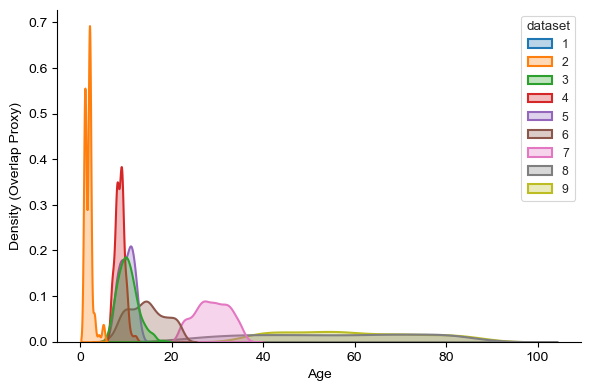

In [3]:


fig, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks", context="paper")

# Usamos common_norm=False para que cada dataset sume 1 independientemente,
# así puedes comparar la distribución de edades sin que el N de cada uno distorsione.
sns.kdeplot(
    data=demo, x='age', hue='dataset', 
    common_norm=False, fill=True, alpha=0.3, linewidth=1.5, ax=ax, palette='tab10'
)

ax.set_xlabel('Age')
ax.set_ylabel('Density (Overlap Proxy)')
sns.despine()

plt.tight_layout()
plt.show()

In [4]:
metrics_df = calculate_graph_metrics(connectomes_cd, connectomes_vd) #variable density connectomes used only for strength and disparity.  
#Controlled density strength is also used for the GAM age-strength GAM comparisson. 
data=pd.DataFrame({'Subject': np.arange(metrics_df.shape[0])})
data=pd.concat([data,demo], axis=1)
data=pd.concat([data, metrics_df], axis=1).to_csv('procdata/demographics_with_graph_metrics.csv', index=False)

In [6]:
data=pd.read_csv('procdata/demographics_with_graph_metrics.csv')
print(data.head())

   Subject  age  sex  dataset  atlas  group  remove_index  Strength  \
0        0    0    0        1      1      1             0  0.999506   
1        1    0    0        1      1      1             0  1.106468   
2        2    0    0        1      1      1             0  1.301185   
3        3    0    1        1      1      1             0  1.239519   
4        4    0    0        1      1      1             0  0.911820   

   Strength_CD  Disparity_Y  Disparity_CD  Clustering_Coefficient  \
0     0.951708     0.225003      0.250867                0.036474   
1     1.035239     0.214476      0.266598                0.035123   
2     1.191552     0.178239      0.232418                0.040813   
3     1.179212     0.232977      0.251770                0.040115   
4     0.845776     0.205915      0.262017                0.029702   

   Average_Shortest_Path  Global_Efficiency      Diameter  Modularity  \
0               2.527934           0.458487  1.000000e+20    0.432573   
1           

In [48]:
# Now we generate distribution plots for each metric, stored in a plots folder.
metrics_to_plot = ['Strength', 'Clustering_Coefficient', 'Global_Efficiency', 'Modularity','Diameter','Disparity_Y']
for metric in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[metric], kde=True, bins=30)
    plt.title(f'Distribution of {metric.capitalize()}')
    plt.xlabel(metric.capitalize())
    plt.ylabel('Frequency')
    plt.savefig(f'results/data_distributions/{metric}_distribution.png')
    plt.close()

---------------------------------------REPLICATION OF PAPER RESULTS ----------------------------------

This was calculated with harmonized data, which we will not finally use, but we anyway reproduce the exact numbers here with harmonized data.

1.- We try to reproduce strength-sex correlation using harmonized data running replication_mousley_age_sex_pval.R obtaining 0.543 as the authors report in Supplementary Fig 3. (run R script after this cell)

In [74]:
demo_harm = pd.read_csv('preprocdata/demographics_harm.csv') #density outliers (14) and non neurotypical (315) have been excluded.
connectomes_vd_harm = read_mat('preprocdata/harmonized_data.mat')['harmonized_data']['connectomes']['variable_density']['normalized_weighted'] #variable density for our analysis.
connectomes_cd_harm = read_mat('preprocdata/harmonized_data.mat')['harmonized_data']['connectomes']['controlled_density']['normalized_weighted'] #constant density.
metrics_df_harm = calculate_graph_metrics(connectomes_cd_harm, connectomes_vd_harm) #variable density connectomes used only for strength and disparity.  
#Controlled density strength is also used for the GAM age-strength GAM comparisson. 
data_harm=pd.DataFrame({'Subject': np.arange(metrics_df_harm.shape[0])})
data_harm=pd.concat([data_harm,demo_harm], axis=1)
data_harm=pd.concat([data_harm, metrics_df_harm], axis=1).to_csv('procdata/demographics_with_graph_metrics_harm.csv', index=False)

c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\pymatreader\utils.py:304: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


2.- We try to reproduce strength-age correlation for different epochs (Tab. 2 for r values and and Suppl table 4 for p-vals) using GAM results of replication_mousley_age_epochs.R to get the residuals and Python to analyze in this script. 

In [22]:
input_data = pd.read_csv('procdata/strength_residuals.csv') #GAM residuals for strength calculated in R. Calculated in replication_muosley_age_epochs.R

# Epochs: inclusive bounds. 
epoch_ranges = [
    (0, 9),
    (9, 32),
    (32, 66),
    (66, 83),
    (83, 90)
]

rows = []

# Replicación exacta del bucle de la autora (usando input_data, NO grouped_data)
for epoch_index, (start, end) in enumerate(epoch_ranges):
    # Filtrar sujeto a sujeto
    epoch_data = input_data[(input_data['age'] >= start) & (input_data['age'] <= end)]
    
    # Extraer variables (col 1 es strength, col 0 es age)
    y = epoch_data.iloc[:, 0]  # Age
    measure = epoch_data.iloc[:, 1]  # Strength (residuos)
    
    if len(epoch_data) > 2:
        r, p = stats.pearsonr(measure, y)
        rows.append({
            "Epoch": epoch_index + 1,
            "Age Range": f"{start}-{end}",
            "N_subjects": epoch_data.shape[0],
            "r": round(r, 4),
            "p": p
        })

df_results = pd.DataFrame(rows)
display(df_results)


,Epoch,Age Range,N_subjects,r,p
0,1,0-9,733,0.1250,6.931927e-04
1,2,9-32,1728,0.2115,6.215775e-19
2,3,32-66,1092,0.2405,7.789481e-16
3,4,66-83,406,0.0094,8.500114e-01
4,5,83-90,93,0.0281,7.891878e-01


In [ ]:
#Probar con all_data.mat